# Notebook Overview

This Notebook perfoms the SMS Spam Classifier project but using the the Bi RNN architecture to check on model's efficiency

In [46]:
# import libraries
#try:
  # %tensorflow_version only exists in Colab.
  # contains features, bug fixes and other architectures released by tensorflow
  # every night, before official releases by tensorflow
  #!pip install tf-nightly
#except Exception:
  #pass


In [47]:
import tensorflow as tf
import pandas as pd
from tensorflow import keras
#!pip install tensorflow-datasets
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt

print(tf.__version__)


2.20.0


In [48]:
# get data files
!wget https://cdn.freecodecamp.org/project-data/sms/train-data.tsv
!wget https://cdn.freecodecamp.org/project-data/sms/valid-data.tsv

train_file_path = "train-data.tsv"
test_file_path = "valid-data.tsv"

--2026-05-11 13:01:03--  https://cdn.freecodecamp.org/project-data/sms/train-data.tsv
Resolving cdn.freecodecamp.org (cdn.freecodecamp.org)... 172.67.70.149, 104.26.2.33, 104.26.3.33, ...
Connecting to cdn.freecodecamp.org (cdn.freecodecamp.org)|172.67.70.149|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 358233 (350K) [text/tab-separated-values]
Saving to: ‘train-data.tsv.1’

train-data.tsv.1    100%[===================>] 349.84K  --.-KB/s    in 0.02s   

2026-05-11 13:01:03 (15.5 MB/s) - ‘train-data.tsv.1’ saved [358233/358233]

--2026-05-11 13:01:04--  https://cdn.freecodecamp.org/project-data/sms/valid-data.tsv
Resolving cdn.freecodecamp.org (cdn.freecodecamp.org)... 172.67.70.149, 104.26.2.33, 104.26.3.33, ...
Connecting to cdn.freecodecamp.org (cdn.freecodecamp.org)|172.67.70.149|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 118774 (116K) [text/tab-separated-values]
Saving to: ‘valid-data.tsv.1’

valid-data.tsv.1    100%[====

# Understanding the Dataset

In [49]:
#finding out location of where the imported datasets are stored
#loaded onto the current working directory
import os
os.getcwd()

'/content'

In [50]:
# convert tsv tp pandas dataframe
#sep used to identify separator
df_train = pd.read_csv(train_file_path, sep = '\t',header = None)
df_test = pd.read_csv(test_file_path, sep = '\t',header = None)

In [51]:
df_train.head()

,0,1
0,ham,ahhhh...just woken up!had a bad dream about u ...
1,ham,you can never do nothing
2,ham,"now u sound like manky scouse boy steve,like! ..."
3,ham,mum say we wan to go then go... then she can s...
4,ham,never y lei... i v lazy... got wat? dat day ü ...


In [52]:
df_test.head()

,0,1
0,ham,i am in hospital da. . i will return home in e...
1,ham,"not much, just some textin'. how bout you?"
2,ham,i probably won't eat at all today. i think i'm...
3,ham,don‘t give a flying monkeys wot they think and...
4,ham,who are you seeing?


In [53]:
df_test.shape

(1392, 2)

In [54]:
df_train.shape

(4179, 2)

In [55]:
#unique labels
df_train[0].unique()

array(['ham', 'spam'], dtype=object)

In [56]:
# converting labels to integers

df_train[0]= df_train[0].replace(('ham','spam'),(0,1))#modifies dataset in place
df_test[0] = df_test[0].replace(('ham','spam'),(0,1))

/tmp/ipykernel_11283/514388700.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_train[0]= df_train[0].replace(('ham','spam'),(0,1))#modifies dataset in place
/tmp/ipykernel_11283/514388700.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_test[0] = df_test[0].replace(('ham','spam'),(0,1))


In [57]:
#visualizing changes
df_train.head()

,0,1
0,0,ahhhh...just woken up!had a bad dream about u ...
1,0,you can never do nothing
2,0,"now u sound like manky scouse boy steve,like! ..."
3,0,mum say we wan to go then go... then she can s...
4,0,never y lei... i v lazy... got wat? dat day ü ...


In [58]:
# extracting features and labels as numpy
X = df_train[1].values
Y = df_train[0].values


In [59]:
#coverting datasetto tokens
#using tokenizer
#most frequent words are assigned common integers

from tensorflow.keras.preprocessing.text import Tokenizer
tokenizer = Tokenizer() #call tokenizer object
tokenizer.fit_on_texts(X) #perfoms tokenization

In [60]:
# word to intger mapping
word2index = tokenizer.word_index
list(word2index.items())[:10]

[('i', 1),
 ('to', 2),
 ('you', 3),
 ('a', 4),
 ('the', 5),
 ('u', 6),
 ('and', 7),
 ('in', 8),
 ('is', 9),
 ('me', 10)]

In [61]:
# getting size of vocab

VOCAB_SIZE = len(word2index)

In [62]:
# apply mappings
sent2int = tokenizer.texts_to_sequences(X)
#convert to numpy array for easier operations
print(sent2int[0])

[3666, 36, 2482, 44, 142, 4, 401, 766, 78, 6, 725, 23, 1, 93, 55, 6, 162, 19, 1, 460, 54, 176, 78, 1615, 110, 24, 1, 314, 153, 44, 12, 14]


In [63]:
len(sent2int[7])
len(sent2int[0])

max(len(sent) for sent in sent2int)

189

# Padding Sequences

Since sequences are of different lengths as observed in the cell above it would be best to pad them to allow for uniform inputs.
To do that I need to identify a maximum length for which ill pad

## Plotting histogram to visualize distribution of sequences lengths

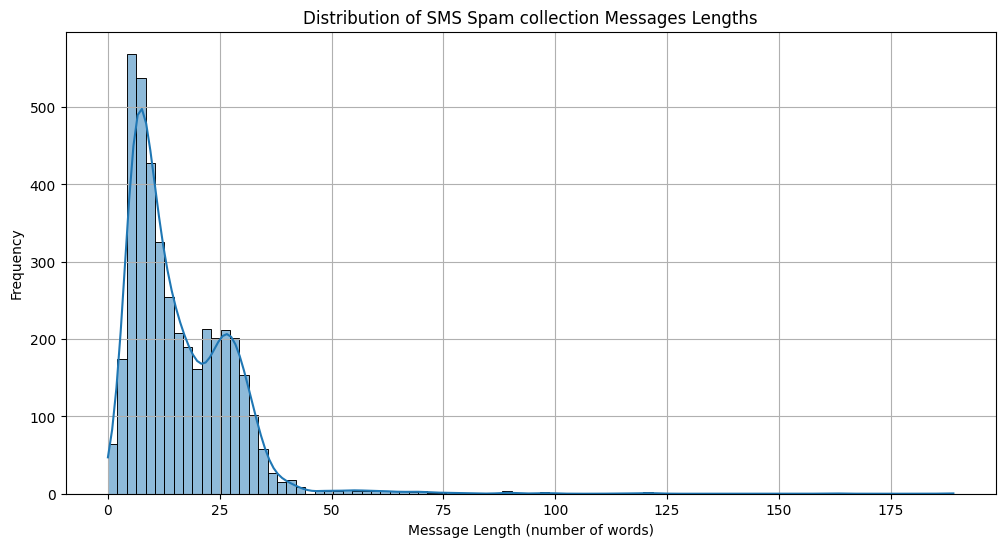

In [64]:
train_message_lengths  = [len(message_length) for message_length in sent2int]
import matplotlib.pyplot as plt
import seaborn as sns #built on top of the matplotlib for better visualizations


# Combine lengths for overall distribution analysis
all_review_lengths = train_message_lengths
plt.figure(figsize=(12, 6))
sns.histplot(all_review_lengths, kde=True)
plt.title('Distribution of SMS Spam collection Messages Lengths')
plt.xlabel('Message Length (number of words)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Conclusion

As the message length approaches more than 50 words the frequency drastically drops. To verify this Ill get the 95th percentile to see what length captures most reviews

In [65]:
length = np.percentile(all_review_lengths, 95)
print(length)
# 33 captures most length of reviews messages are writen

33.0


In [66]:
# To be safe ill set the maxlen to 50 to avoid losing critical information
maxlen = 50

from tensorflow.keras.preprocessing import sequence
# padding
#truncating = 'post' extra words are dropped from the end

pad_seq = sequence.pad_sequences(sent2int,maxlen = maxlen, padding = 'post',truncating='post')

In [67]:
pad_seq[0]

array([3666,   36, 2482,   44,  142,    4,  401,  766,   78,    6,  725,
         23,    1,   93,   55,    6,  162,   19,    1,  460,   54,  176,
         78, 1615,  110,   24,    1,  314,  153,   44,   12,   14,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0], dtype=int32)

# Converting dataset to a tf.data.Dataset object

tf.data.Dataset object allows model to perfom useful resources such as batching, shuffling and mapping. It also allows parallel processing where CPU prepares next batches while GPU processes  a batch avoiding keeping the processor idle

In [68]:
sliced_data = tf.data.Dataset.from_tensor_slices((pad_seq, Y))

In [69]:
sliced_data.element_spec
# TensorSpec(shape=(50,) 1D with 50 elements representing individual sequences
#

(TensorSpec(shape=(50,), dtype=tf.int32, name=None),
 TensorSpec(shape=(), dtype=tf.int64, name=None))

In [70]:
# batching and shuffling
train_data = sliced_data.shuffle(5000).batch(32)

# Model Architecure

In [71]:
input_dim = VOCAB_SIZE
embed_dim = 50 #dense vector representations to capture semantic meaning of words
LSTM_units = 64#number of processors

In [72]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dense, SimpleRNN, Embedding, Input, Bidirectional

model = Sequential()
model.add(Embedding(input_dim, embed_dim, mask_zero = True)) #mask zero ignores padded values
model.add(Bidirectional(SimpleRNN(64)))
model.add(Dense(1, activation='sigmoid'))

model.build((32,maxlen)) #batch size and input length
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (32, 50, 50)           │       384,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (32, 128)              │        14,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (32, 1)                │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 399,449 (1.52 MB)

 Trainable params: 399,449 (1.52 MB)

 Non-trainable params: 0 (0.00 B)

# Model compilation


In [73]:
model.compile(optimizer = 'adam',
              loss = 'binary_crossentropy',
              metrics = ['accuracy'])

In [74]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(pad_seq, Y, test_size=0.2, random_state=42)

# Create tf.data.Dataset for training
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(len(X_train) + 1000).batch(32)

# Create tf.data.Dataset for validation
val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(32)

history = model.fit(train_dataset, epochs=5, validation_data=val_dataset)


Epoch 1/5
105/105 ━━━━━━━━━━━━━━━━━━━━ 10s 58ms/step - accuracy: 0.9144 - loss: 0.2509 - val_accuracy: 0.9498 - val_loss: 0.1689
Epoch 2/5
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9871 - loss: 0.0529 - val_accuracy: 0.9868 - val_loss: 0.0573
Epoch 3/5
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9982 - loss: 0.0153 - val_accuracy: 0.9713 - val_loss: 0.0866
Epoch 4/5
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9988 - loss: 0.0088 - val_accuracy: 0.9844 - val_loss: 0.0685
Epoch 5/5
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 1.0000 - loss: 0.0024 - val_accuracy: 0.9844 - val_loss: 0.0790


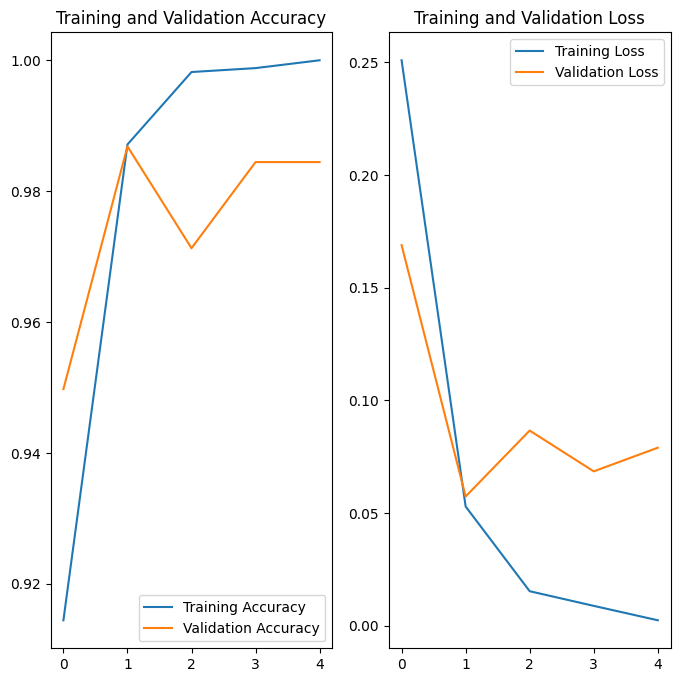

In [75]:
# visualizing loss
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(5)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [76]:
# any test and validation data must be in the same format as the training data
def encode(text):
  tokens = tf.keras.preprocessing.text.text_to_word_sequence(text) #returns a list of words split into separate tokens
  integers = [word2index[word] if word in word2index else 0 for word in tokens]
  pad_int = sequence.pad_sequences([integers],maxlen,truncating = 'post', padding = 'post')

  return pad_int

# Models Perfomance

In [77]:
test_seq = df_test[1].values
test_labels = df_test[0].values

preprocessed_seq = []
for test_inputs in test_seq:
  preprocessed_seq.extend(encode(test_inputs))

preprocessed_seq[0].shape

test_generator = tf.data.Dataset.from_tensor_slices((preprocessed_seq,test_labels))
test_generator = test_generator.batch(32) #returns batches of 32
loss,accuracy = model.evaluate(test_generator)
print(f"{accuracy *100:.2f} accuracy")

44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9864 - loss: 0.0558
98.64 accuracy


In [78]:
# function to predict messages based on model
# (should return list containing prediction and label, ex. [0.008318834938108921, 'ham'])
def predict_message(pred_text):
  pred_int = encode(pred_text)
  prediction = model.predict(pred_int)

  if prediction[0][0] > 0.5:

    results = prediction[0][0]
    prediction = [results, 'spam']

  else:
    results = prediction[0][0]
    prediction = [results, 'ham']




  return prediction

pred_text = "how are you doing today?"

prediction = predict_message(pred_text)
print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 548ms/step
[np.float32(0.0011028586), 'ham']


In [45]:
# Run this cell to test your function and model. Do not modify contents.
def test_predictions():
  test_messages = ["how are you doing today",
                   "sale today! to stop texts call 98912460324",
                   "i dont want to go. can we try it a different day? available sat",
                   "our new mobile video service is live. just install on your phone to start watching.",
                   "you have won £1000 cash! call to claim your prize.",
                   "i'll bring it tomorrow. don't forget the milk.",
                   "wow, is your arm alright. that happened to me one time too"
                  ]

  test_answers = ["ham", "spam", "ham", "spam", "spam", "ham", "ham"]
  passed = True

  for msg, ans in zip(test_messages, test_answers):
    prediction = predict_message(msg)
    if prediction[1] != ans:
      passed = False

  if passed:
    print("You passed the challenge. Great job!")
  else:
    print("You haven't passed yet. Keep trying.")

test_predictions()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
You passed the challenge. Great job!
